In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

#Vježba1e
Preuzmite datoteku podaci_np.csv sa Merlina. Učitajte podatke iz datoteke i primijenite np.polyfit da bi saznali kojeg stupnja je polinom koji se koristio za generiranje drugog stupca tih podataka. U prvom stupcu je značajka, a u drugom target vrijednosti. Krenite od polinoma prvog stupnja (vrijednost: 1) i gledajte kolika je greška (RMSE). Povećavajte stupanj polinoma za jedan i kad pogodite stupanj, greška će biti znatno manja od 1. Predajte gotov program (.ipynb) kad vam greška bude manja od 1.

In [2]:
df = pd.read_csv("/content/podaci_np.csv")
df.head()

,X,Y
0,0,1
1,1,4
2,2,13
3,3,34
4,4,73


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X       51 non-null     int64
 1   Y       51 non-null     int64
dtypes: int64(2)
memory usage: 948.0 bytes


             Train Error    Test Error
Complexity                            
1           1.453992e+04  1.552572e+04
2           2.608113e+03  2.074021e+03
3           4.672891e-11  5.507514e-11
4           2.891469e-11  2.586545e-11
5           2.178104e-11  2.101698e-11
6           5.303903e-11  6.204250e-11
7           2.924460e-11  2.854457e-11
8           2.412816e-11  2.640497e-11
9           8.387597e-12  1.202637e-11


<Axes: xlabel='Complexity'>

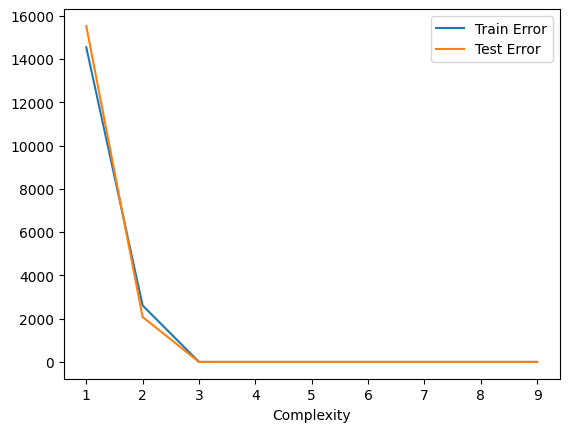

In [8]:
X = df.iloc[:, 0].values
y = df.iloc[:, 1].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

results = []

for complexity in [1, 2, 3, 4, 5, 6, 7, 8, 9]:
    model = np.poly1d(np.polyfit(X_train, y_train, complexity))

    train_error = np.sqrt(mean_squared_error(y_train, model(X_train)))
    test_error = np.sqrt(mean_squared_error(y_test, model(X_test)))

    results.append((complexity, train_error, test_error))


columns = ["Complexity", "Train Error", "Test Error"]
results_df = pd.DataFrame.from_records(results,
columns=columns,
index="Complexity")
print(results_df)
results_df.plot()

#Zaključak: polinom 3. stupnja najbolje opisuje podatke iz oba stupca